In [11]:
# 1-D Double Integrator Problem
import numpy as np
import mosek.fusion as mf
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import sys
from plot_ellipse import confidence_ellipse
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
from numpy.random import default_rng
from scipy.io import loadmat # necessary to import the .mat file of the previous analysis


In [12]:
# The code below solves the problem of covariance steering and also mean control
# in the case where the final covariance is a pre-defined matrix (for chance constraint,
# namely a constraint that has to be satisfied with a certain probability, we need to rely
# to other algorithms.

In [13]:
# --------------------------
# Problem setup
# --------------------------
dt = 3.5 # length of each time step
n = 4  # state dimension
m = 2  # control dimension
N = 101  # number of nodes in the time grid
t = np.arange(N+1) * dt  # Time vector

rng = default_rng(1) # seed 1 for reproducibility
Nsamples = 1000
gv2 = 1.00520451e-15
V = 149597870.7 / (24*3600)

# Discrete-time double integrator
# All matrices are defined as a list of matrices (one for each time step, 0,1,..., N-1)
Am = [mf.Matrix.dense(np.array([[1, 0, dt, 0], [0, 1, 0, dt], [1e-3, 1e-3, 1, 0], [1e-3, 1e-3, 0, 1]])) for _ in range(N)]
Bm = [mf.Matrix.dense(np.array([[0., 0.], [0., 0.], [dt, 0.], [0., dt]])) for _ in range(N)]
DmDmT = [mf.Matrix.dense(np.diag([0,0,gv2,gv2])) for _ in range(N)]  # small process noise

# Cost matrices
Q_param = mf.Matrix.dense(np.eye(n))
R_param = mf.Matrix.dense(np.eye(m))

# Boundary conditions
Si = np.diag([4.5e-15, 4.5e-15, 3.5e-9, 3.5e-9])
Sf = np.diag([4.5e-6, 4.5e-6, 3.5e-9, 3.5e-9])
mu_i = np.array([-0.94052, -0.34502, 9.7746/V, -28.078/V])
mu_f = np.array([-1.1543,   1.1829, -16.427/V, -14.861/V])

In [14]:
# --------------------------
# 1. Mean Control Problem
# --------------------------
M_mean = mf.Model("mean_control")

# Variables
v = [M_mean.variable(f"v{k}", [m], mf.Domain.unbounded()) for k in range(N)]
V = [M_mean.variable(f"V{_k}", mf.Domain.inPSDCone(m)) for _k in range(N)]
mu = [M_mean.variable(f"mu{k}", [n], mf.Domain.unbounded()) for k in range(N + 1)]
Mmu = [M_mean.variable(f"Mmu{_k}", mf.Domain.inPSDCone(n)) for _k in range(N+1)]

J_mean = mf.Expr.constTerm(0.0)

for k in range(N):
    # Mean propagation
    M_mean.constraint(
        mf.Expr.sub(mu[k+1], mf.Expr.add(mf.Expr.mul(Am[k], mu[k]), mf.Expr.mul(Bm[k], v[k]))),
        mf.Domain.equalsTo(0.0)
    )

    # Relaxations
    PSD_block_v = mf.Expr.stack([[V[k], v[k]], [mf.Expr.transpose(v[k]), mf.Expr.constTerm(1.0)]])
    M_mean.constraint(PSD_block_v, mf.Domain.inPSDCone(m+1))

    PSD_block_mu = mf.Expr.stack([[Mmu[k], mu[k]], [mf.Expr.transpose(mu[k]), mf.Expr.constTerm(1.0)]])
    M_mean.constraint(PSD_block_mu, mf.Domain.inPSDCone(n+1))

    # Cost
    J_mean = mf.Expr.add(J_mean, mf.Expr.dot(R_param, V[k]))
    J_mean = mf.Expr.add(J_mean, mf.Expr.dot(Q_param, Mmu[k]))

# Boundary conditions
M_mean.constraint(mf.Expr.sub(mu[0], mf.Matrix.dense(mu_i[:, None])), mf.Domain.equalsTo(0.0))
M_mean.constraint(mf.Expr.sub(mu[N], mf.Matrix.dense(mu_f[:, None])), mf.Domain.equalsTo(0.0))

M_mean.objective(mf.ObjectiveSense.Minimize, J_mean)
M_mean.setLogHandler(sys.stdout)
M_mean.solve()
print("Mean Problem status:", M_mean.getProblemStatus())


Problem
  Name                   : mean_control    
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 412             
  Affine conic cons.     : 202 (2121 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 611             
  Matrix variables       : 203 (scalarized: 1323)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 402
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 succes

In [15]:
# --------------------------
# 2. Covariance Steering Problem
# --------------------------
M_cov = mf.Model("covariance_steering")

# Variables
Y = [M_cov.variable(f"Y{k}", mf.Domain.inPSDCone(m)) for k in range(N)]
U = [M_cov.variable(f"U{k}", [m, n], mf.Domain.unbounded()) for k in range(N)]
S = [M_cov.variable(f"S{k}", mf.Domain.inPSDCone(n)) for k in range(N + 1)]

J_cov = mf.Expr.constTerm(0.0)

for k in range(N):
    # Covariance propagation
    constr = mf.Expr.neg(S[k + 1])
    constr = mf.Expr.add(constr, mf.Expr.mul(mf.Expr.mul(Am[k], S[k]), mf.Matrix.transpose(Am[k])))
    constr = mf.Expr.add(constr, mf.Expr.mul(mf.Expr.mul(Bm[k], U[k]), mf.Matrix.transpose(Am[k])))
    constr = mf.Expr.add(constr, mf.Expr.mul(mf.Expr.mul(Am[k], mf.Matrix.transpose(U[k])), mf.Matrix.transpose(Bm[k])))
    constr = mf.Expr.add(constr, mf.Expr.mul(mf.Expr.mul(Bm[k], Y[k]), mf.Matrix.transpose(Bm[k])))
    constr = mf.Expr.add(constr, DmDmT[k])
    M_cov.constraint(constr, mf.Domain.equalsTo(0.0))

    # LMI constraint
    X = mf.Expr.stack([[S[k], mf.Expr.transpose(U[k])], [U[k], Y[k]]])
    M_cov.constraint(X, mf.Domain.inPSDCone(n + m))

    # Cost
    J_cov = mf.Expr.add(J_cov, mf.Expr.dot(Q_param, S[k]))
    J_cov = mf.Expr.add(J_cov, mf.Expr.dot(R_param, Y[k]))

# Boundary conditions
M_cov.constraint(mf.Expr.sub(S[0], mf.Matrix.dense(Si)), mf.Domain.equalsTo(0.0))
M_cov.constraint(mf.Expr.sub(S[N], mf.Matrix.dense(Sf)), mf.Domain.equalsTo(0.0))

M_cov.objective(mf.ObjectiveSense.Minimize, J_cov)
M_cov.setLogHandler(sys.stdout)
M_cov.solve()
print("Covariance Problem status:", M_cov.getProblemStatus())


Problem
  Name                   : covariance_steering
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 1648            
  Affine conic cons.     : 101 (2121 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 809             
  Matrix variables       : 203 (scalarized: 1323)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 succe

In [16]:
# Optimization solved in the previous two cells (split into Mean and Covariance problems)


In [17]:
# --------------------------
# Extract and process results
# --------------------------
mu_opt = []
S_opt = []
K_k = []

for k in range(N + 1):
    mu_k = mu[k].level()
    mu_opt.append(np.array(mu_k))

    S_k_flat = S[k].level()
    S_k_reshaped = np.array(S_k_flat).reshape((n, n))
    S_opt.append(S_k_reshaped)

for k in range(N):
    U_k_flat = U[k].level()
    U_k_reshaped = np.array(U_k_flat).reshape((m, n))
    K_k.append(U_k_reshaped @ np.linalg.inv(S_opt[k]))
    print(K_k[k])

# Convert mu_opt to shape (N+1, n)
mu_array = np.array([np.ravel(mu) for mu in mu_opt])  # shape (N+1, 2) since n=2 (2 states pos, vel)
# Extract optimal mean controls v_opt as numpy array shape (N, m)
v_opt = np.array([np.ravel(vk.level()) for vk in v])  # shape (N, m)
# If m = 1 you'll get shape (N,1). For convenience make it (N,) in that case:
if v_opt.shape[1] == 1:
    v_opt = v_opt.ravel()   # shape (N,)

print(K_k[10])

[[-1.78252592e-01 -1.30412311e-05 -2.30533441e-02 -3.16464197e-05]
 [ 7.88576645e-05 -3.10586190e-01 -3.38609855e-05 -1.14853973e-02]]
[[-0.9887298  -0.025294   -3.68309174 -0.09748504]
 [ 0.00782417  1.73696985  0.02980597  6.79153119]]
[[-4.22059839e-02  1.31035425e-04 -2.05117538e-02 -4.47706184e-05]
 [ 1.41045940e-04 -4.35079499e-02 -4.36311196e-05 -3.25325914e-02]]
[[-4.41400550e-02  1.18598111e-04 -6.48682466e-02 -4.14195448e-05]
 [ 1.29953742e-04 -3.84729968e-02 -3.98704935e-05  1.46708616e-02]]
[[-3.88129408e-02  1.30182555e-04  3.21687295e-04 -3.54911552e-05]
 [ 1.18609576e-04 -3.61423063e-02 -4.00127370e-05  4.29393672e-02]]
[[-3.91869865e-02  1.20143512e-04  5.20320315e-03 -3.97214181e-05]
 [ 1.19134184e-04 -4.28157495e-02 -3.92207220e-05 -4.98585746e-02]]
[[-4.38463744e-02  1.21352269e-04 -6.41092281e-02 -4.25863045e-05]
 [ 1.57471594e-04 -4.38130393e-02 -3.38602544e-05 -6.10821325e-02]]
[[-4.13693484e-02  1.06741537e-04 -3.19250522e-02 -3.93220129e-05]
 [ 1.55146418e-04 -4

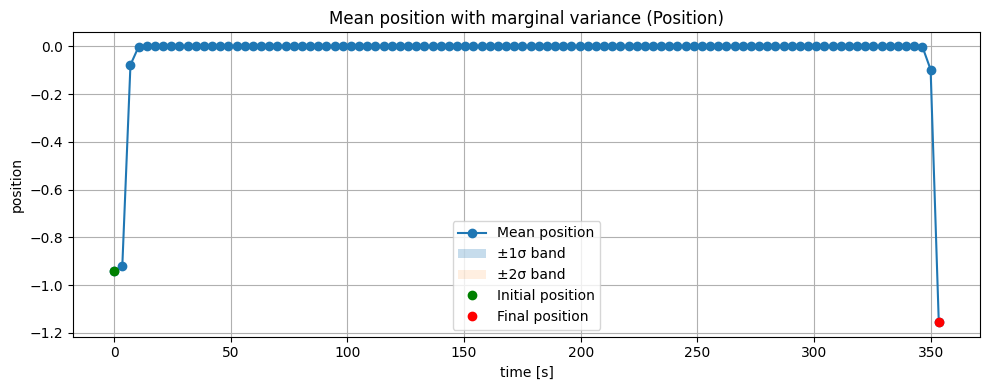

In [18]:
# --------------------------
# Plot 1: Pos. Mean trajectory
# --------------------------

# Convert S_opt into a list of nxn numpy arrays, and extract position variance
S_arr = [np.array(Sk).reshape((n, n)) for Sk in S_opt]
pos_var = np.array([Sk[0, 0] for Sk in S_arr])

# Guard against tiny negative values due to numerical issues
pos_var = np.clip(pos_var, a_min=0.0, a_max=None)
pos_std = np.sqrt(pos_var)

# --- Plot position vs time with ±1σ and ±2σ bands ---
fig1, ax = plt.subplots(figsize=(10, 4))

ax.plot(t, mu_array[:, 0], marker='o', linestyle='-', label='Mean position')
ax.fill_between(t, mu_array[:, 0] - pos_std, mu_array[:, 0] + pos_std,
                alpha=0.25, label='±1σ band')
ax.fill_between(t, mu_array[:, 0] - 2*pos_std, mu_array[:, 0] + 2*pos_std,
                alpha=0.12, label='±2σ band')

# Mark initial and final
ax.plot(t[0], mu_array[0, 0], 'go', label='Initial position')
ax.plot(t[-1], mu_array[-1, 0], 'ro', label='Final position')

ax.set_xlabel('time [s]')
ax.set_ylabel('position')
ax.set_title('Mean position with marginal variance (Position)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

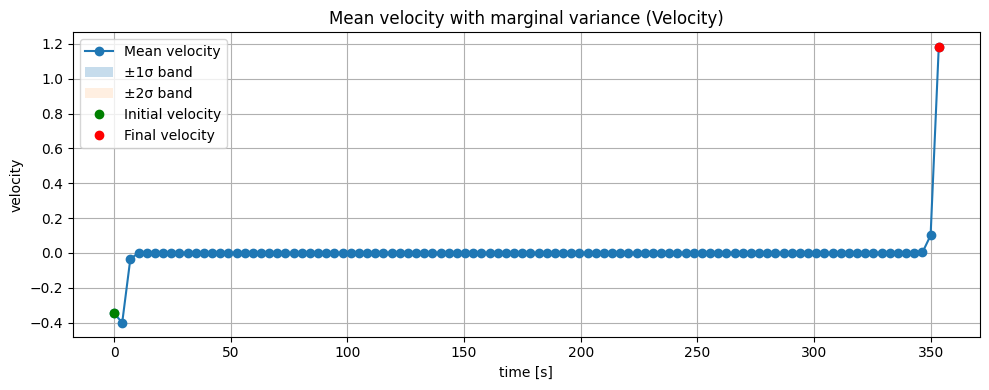

In [19]:
# --------------------------
# Plot 2: Vel. Mean trajectory
# --------------------------

# Convert S_opt into a list of nxn numpy arrays, and extract velocity variance
S_arr = [np.array(Sk).reshape((n, n)) for Sk in S_opt]
vel_var = np.array([Sk[1, 1] for Sk in S_arr])

# Guard against tiny negative values due to numerical issues
vel_var = np.clip(vel_var, a_min=0.0, a_max=None)
vel_std = np.sqrt(vel_var)

# --- Plot velocity vs time with ±1σ and ±2σ bands ---
fig2, ax = plt.subplots(figsize=(10, 4))

ax.plot(t, mu_array[:, 1], marker='o', linestyle='-', label='Mean velocity')
ax.fill_between(t, mu_array[:, 1] - vel_std, mu_array[:, 1] + vel_std,
                alpha=0.25, label='±1σ band')
ax.fill_between(t, mu_array[:, 1] - 2*vel_std, mu_array[:, 1] + 2*vel_std,
                alpha=0.12, label='±2σ band')

# Mark initial and final
ax.plot(t[0], mu_array[0, 1], 'go', label='Initial velocity')
ax.plot(t[-1], mu_array[-1, 1], 'ro', label='Final velocity')

ax.set_xlabel('time [s]')
ax.set_ylabel('velocity')
ax.set_title('Mean velocity with marginal variance (Velocity)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

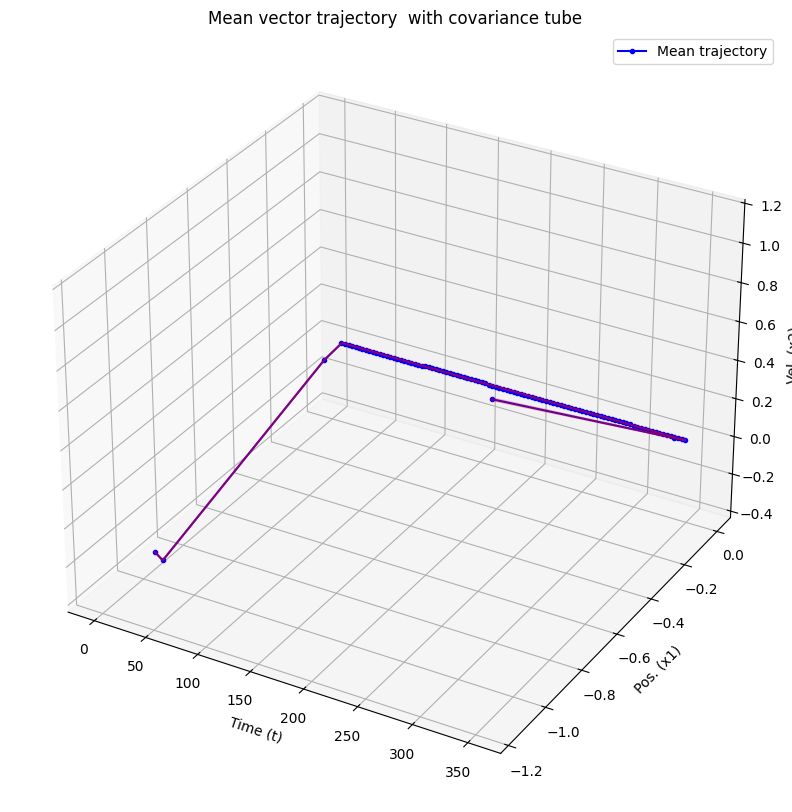

In [20]:
# --------------------------
# Plot 3: 3D Tube Plot
# --------------------------
sigma_mult = 1.0  # 1-sigma tube (~68% confidence), 2.0 = 2-sigma (~95%)
upper_bound = mu_array + sigma_mult * np.array([np.sqrt(np.diag(S)) for S in S_opt])
lower_bound = mu_array - sigma_mult * np.array([np.sqrt(np.diag(S)) for S in S_opt])

fig3 = plt.figure(figsize=(10,10))
ax = fig3.add_subplot(111, projection='3d')

# Plot mean trajectory (Both for position and velocity)
ax.plot(t, mu_array[:,0], mu_array[:,1], 'b.-', label='Mean trajectory')

# Plot “tube” by plotting lines for upper and lower bounds
ax.plot(t, upper_bound[:,0], upper_bound[:,1], color='r', alpha=0.3)
ax.plot(t, lower_bound[:,0], lower_bound[:,1], color='r', alpha=0.3)

# Fill between (rough approximation)
for k in range(N):
    ax.plot([t[k], t[k]],
            [lower_bound[k,0], upper_bound[k,0]],
            [lower_bound[k,1], upper_bound[k,1]],
            color='r', alpha=0.1)

# Labels
ax.set_xlabel("Time (t)")
ax.set_ylabel("Pos. (x1)")
ax.set_zlabel("Vel. (x2)")
ax.set_title("Mean vector trajectory  with covariance tube")
ax.legend()
plt.show()